
Found experiments:
   Flat XLMR
   Gold_routing
   Hard_routing
   Parent Shared Expert
   Parent_Conditioned_Hierarchica
   shared_multiCore_XLM-R_diffWeightsBoth


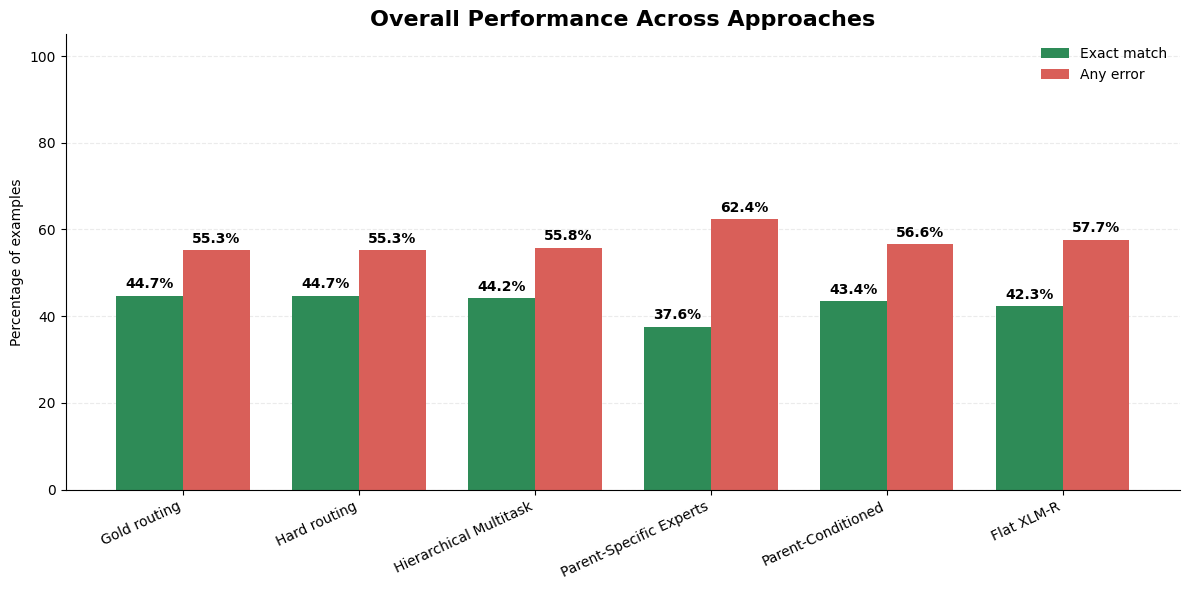


Saved: C:\Users\alrazz\Downloads\comparison_plots\overall_performance.png


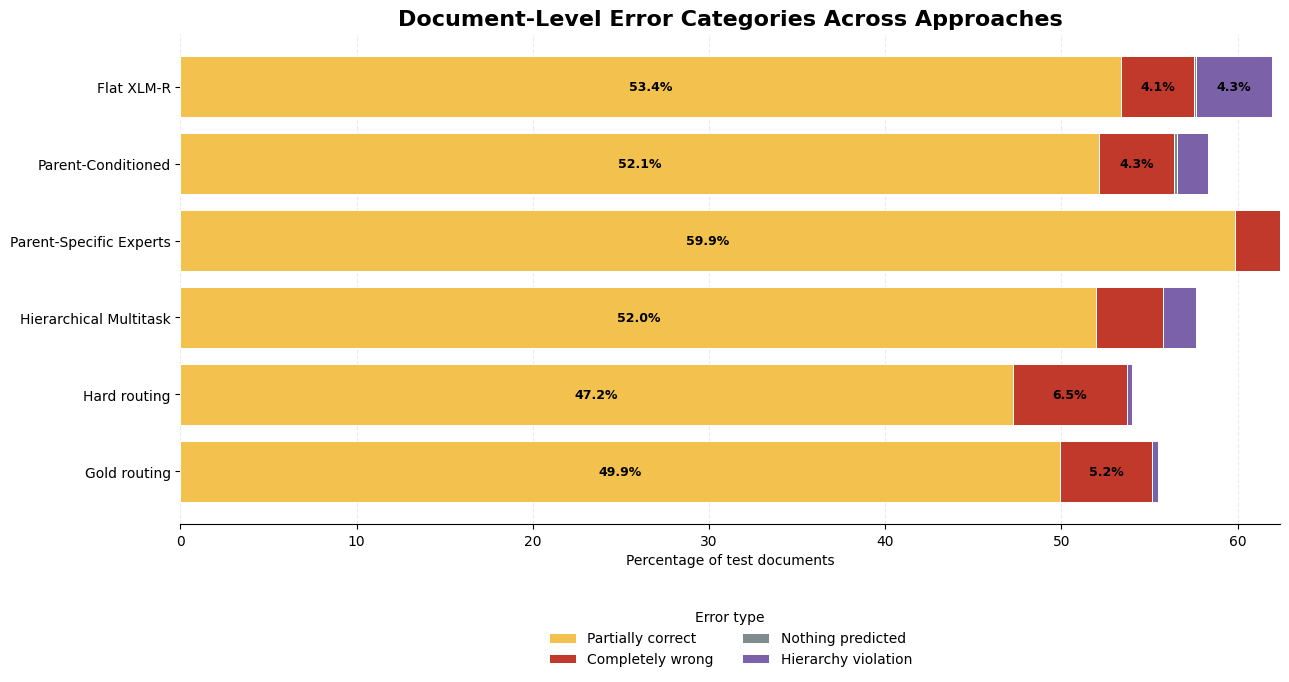

Saved: C:\Users\alrazz\Downloads\comparison_plots\error_composition.png


================ SUMMARY ================

category                 exact_match  any_error  partially_correct  completely_wrong  nothing_predicted  hierarchy_violation
Gold routing                   44.71      55.29              49.92              5.21               0.00                 0.32
Hard routing                   44.71      55.29              47.24              6.48               0.00                 0.32
Hierarchical Multitask         44.23      55.77              51.97              3.79               0.00                 1.90
Parent-Specific Experts        37.60      62.40              59.87              2.53               0.00                 0.00
Parent-Conditioned             43.44      56.56              52.13              4.27               0.16                 1.74
Flat XLM-R                     42.34      57.66              53.40              4.11               0.16                 4.27




In [9]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# SETTINGS
# ============================================================

ROOT = Path(r"C:\Users\alrazz\Downloads")

CSV_NAME = "per_label_tuned_document_summary.csv"
SUBFOLDER = "hierarchical_error_analysis"

OUTPUT_DIR = ROOT / "comparison_plots"
OUTPUT_DIR.mkdir(exist_ok=True)


# ============================================================
# Find all experiments
# ============================================================

csv_files = list(ROOT.glob(f"*/{SUBFOLDER}/{CSV_NAME}"))

if not csv_files:
    raise FileNotFoundError(
        f"No files found matching:\n"
        f"{ROOT}\\*\\{SUBFOLDER}\\{CSV_NAME}"
    )


print("\nFound experiments:")
for f in csv_files:
    print("  ", f.parent.parent.name)


# ============================================================
# Read all experiments
# ============================================================

experiments = {}

for csv_file in csv_files:

    experiment_name = csv_file.parent.parent.name

    df = pd.read_csv(csv_file)

    required = {"category", "count", "percentage"}

    missing = required - set(df.columns)

    if missing:
        print(
            f"\nWARNING: {experiment_name} is missing "
            f"columns: {missing}"
        )
        continue

    experiments[experiment_name] = df


if not experiments:
    raise ValueError("No valid experiment files found.")


# ============================================================
# Convert to one table
# ============================================================

all_data = []

for experiment_name, df in experiments.items():

    temp = df.copy()
    temp["experiment"] = experiment_name

    all_data.append(temp)


data = pd.concat(all_data, ignore_index=True)


# ============================================================
# Create experiment x category table
# ============================================================

pivot = data.pivot_table(
    index="experiment",
    columns="category",
    values="percentage",
    aggfunc="sum",
    fill_value=0
)


# ============================================================
# Category names
# ============================================================

category_names = {
    "exact_match": "Exact match",
    "any_error": "Any error",
    "partially_correct": "Partially correct",
    "completely_wrong": "Completely wrong",
    "nothing_predicted": "Nothing predicted",
    "hierarchy_violation": "Hierarchy violation",
}


# ============================================================
# Desired experiment order
# ============================================================

preferred_order = [
    "Gold_routing",
    "Hard_routing",
    "shared_multiCore_XLM-R_diffWeightsBoth",
    "Parent Shared Expert",
    "Parent_Conditioned_Hierarchica",
    "Flat XLMR",
]


# Keep only experiments that actually exist
ordered_experiments = [
    x for x in preferred_order
    if x in pivot.index
]


# Add any unexpected experiments
ordered_experiments += [
    x for x in pivot.index
    if x not in ordered_experiments
]


pivot = pivot.reindex(ordered_experiments)


# ============================================================
# Shorter display names
# ============================================================

display_experiment_names = {
    "Gold_routing": "Gold routing",
    "Hard_routing": "Hard routing",
    "shared_multiCore_XLM-R_diffWeightsBoth": "Hierarchical Multitask",
    "Parent Shared Expert": "Parent-Specific Experts",
    "Parent_Conditioned_Hierarchica": "Parent-Conditioned",
    "Flat XLMR": "Flat XLM-R",
}


display_names = [
    display_experiment_names.get(
        x,
        x
    )
    for x in pivot.index
]


# ============================================================
# Colors
# ============================================================

COLORS = {
    "exact_match": "#2E8B57",
    "any_error": "#D95F59",

    "partially_correct": "#F2C14E",
    "completely_wrong": "#C0392B",
    "nothing_predicted": "#7F8C8D",
    "hierarchy_violation": "#7B61A8",
}


# ============================================================
# Plot 1:
# Exact match vs Any error
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 6)
)

x = np.arange(len(pivot))
width = 0.38


exact = pivot["exact_match"].values
errors = pivot["any_error"].values


bars1 = ax.bar(
    x - width / 2,
    exact,
    width,
    label="Exact match",
    color=COLORS["exact_match"]
)

bars2 = ax.bar(
    x + width / 2,
    errors,
    width,
    label="Any error",
    color=COLORS["any_error"]
)


# Add percentage labels
for bars in [bars1, bars2]:

    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )


ax.set_xticks(x)
ax.set_xticklabels(
    display_names,
    rotation=25,
    ha="right"
)

ax.set_ylabel("Percentage of examples")

ax.set_ylim(0, 105)

ax.set_title(
    "Overall Performance Across Approaches",
    fontsize=16,
    fontweight="bold"
)

ax.legend(
    frameon=False,
    loc="upper right"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

output1 = OUTPUT_DIR / "overall_performance.png"

plt.savefig(
    output1,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"\nSaved: {output1}")


# ============================================================
# Plot 2:
# Error composition
# ============================================================

error_categories = [
    "partially_correct",
    "completely_wrong",
    "nothing_predicted",
    "hierarchy_violation",
]

available_error_categories = [
    c for c in error_categories
    if c in pivot.columns
]


fig, ax = plt.subplots(
    figsize=(13, 7)
)


left = np.zeros(len(pivot))


for category in available_error_categories:

    values = pivot[category].values

    bars = ax.barh(
        display_names,
        values,
        left=left,
        label=category_names[category],
        color=COLORS[category],
        edgecolor="white",
        linewidth=0.7
    )

    # Percentage labels
    for i, value in enumerate(values):

        if value >= 4:

            ax.text(
                left[i] + value / 2,
                i,
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold"
            )

    left += values


ax.set_xlabel(
    "Percentage of test documents"
)

ax.set_title(
    "Document-Level Error Categories Across Approaches",
    fontsize=16,
    fontweight="bold"
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.legend(
    title="Error type",
    bbox_to_anchor=(0.5, -0.15),
    loc="upper center",
    ncol=2,
    frameon=False
)

plt.tight_layout()

output2 = OUTPUT_DIR / "error_composition.png"

plt.savefig(
    output2,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {output2}")


# ============================================================
# Print a useful summary table
# ============================================================

print("\n\n================ SUMMARY ================\n")

summary_columns = [
    c for c in [
        "exact_match",
        "any_error",
        "partially_correct",
        "completely_wrong",
        "nothing_predicted",
        "hierarchy_violation",
    ]
    if c in pivot.columns
]

summary = pivot[summary_columns].copy()

summary.index = display_names

summary = summary.round(2)

print(summary.to_string())

print("\n=========================================\n")


# Error types


Found hierarchy-error files:
   Flat XLMR
   Gold_routing
   Hard_routing
   Parent Shared Expert
   Parent_Conditioned_Hierarchica
   shared_multiCore_XLM-R_diffWeightsBoth


HIERARCHY ERROR EVENTS
error_type_display                      Parent predicted, child missed  Hierarchy violation  Child correct, parent missed
experiment                                                                                                               
Gold_routing                                                        82                    2                             1
Hard_routing                                                        86                    2                             1
shared_multiCore_XLM-R_diffWeightsBoth                              75                   12                             3
Parent Shared Expert                                               136                    0                             0
Parent_Conditioned_Hierarchica                                      

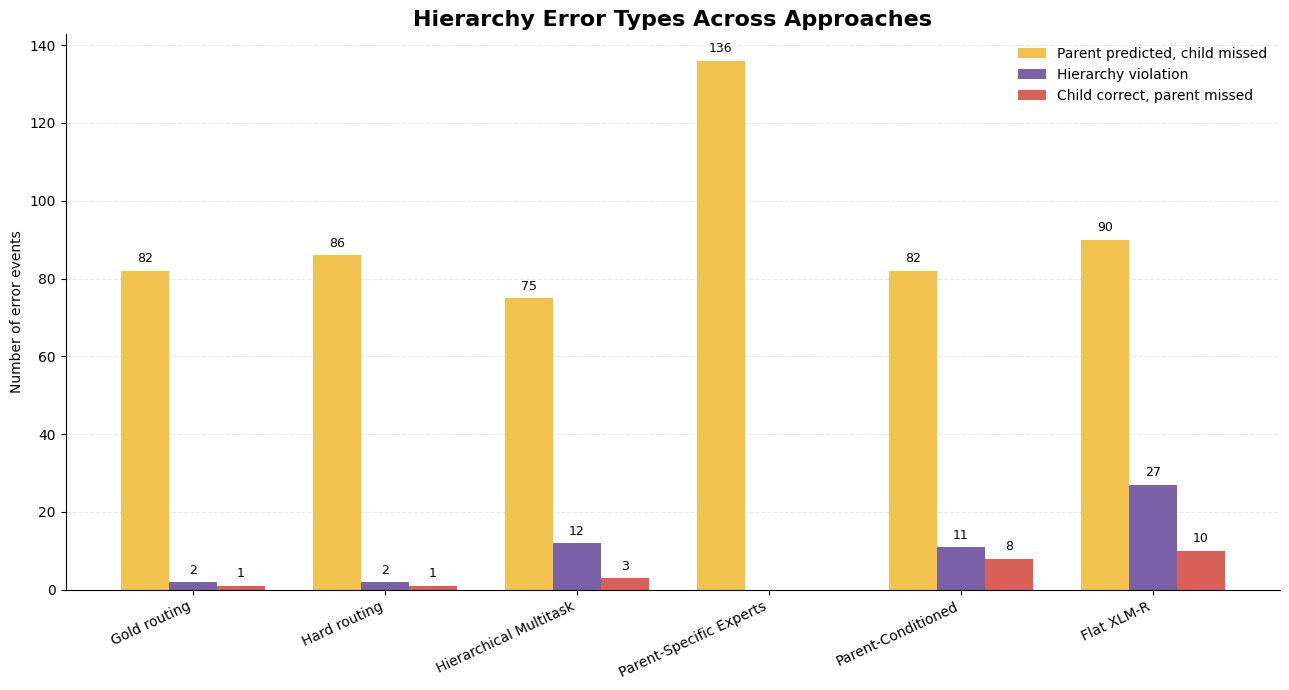


Saved: C:\Users\alrazz\Downloads\comparison_plots\hierarchy_error_comparison\hierarchy_error_types_counts.png


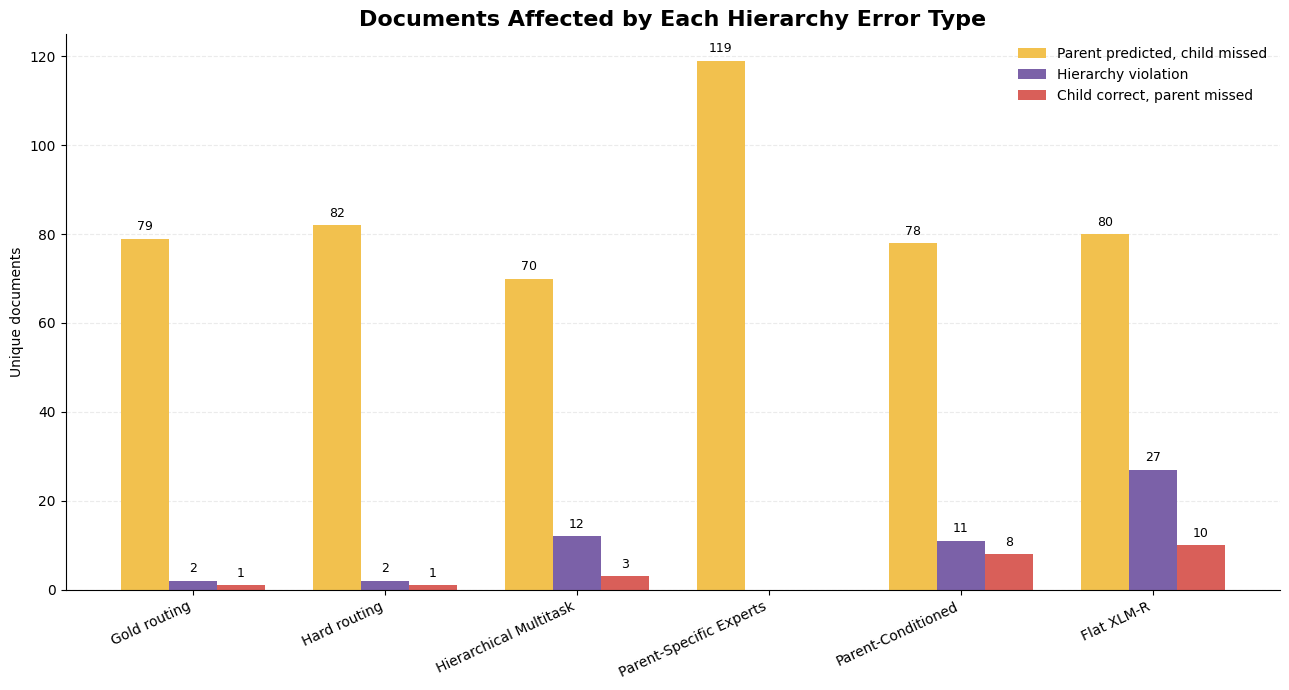


Saved: C:\Users\alrazz\Downloads\comparison_plots\hierarchy_error_comparison\hierarchy_error_types_documents.png


TOP HIERARCHY ERROR PAIRS ACROSS ALL EXPERIMENTS
            error_type_display child parent     pair  total_events  total_unique_document_counts
Parent predicted, child missed   dtp     IN dtp → IN            99                            99
Parent predicted, child missed    ob     OP  ob → OP            62                            62
Parent predicted, child missed    av     OP  av → OP            59                            59
Parent predicted, child missed    rv     OP  rv → OP            54                            54
Parent predicted, child missed    ds     IP  ds → IP            35                            35
Parent predicted, child missed    fi     IN  fi → IN            28                            28
Parent predicted, child missed    lt     IN  lt → IN            26                            26
Parent predicted, child missed    rs     OP  rs → OP       

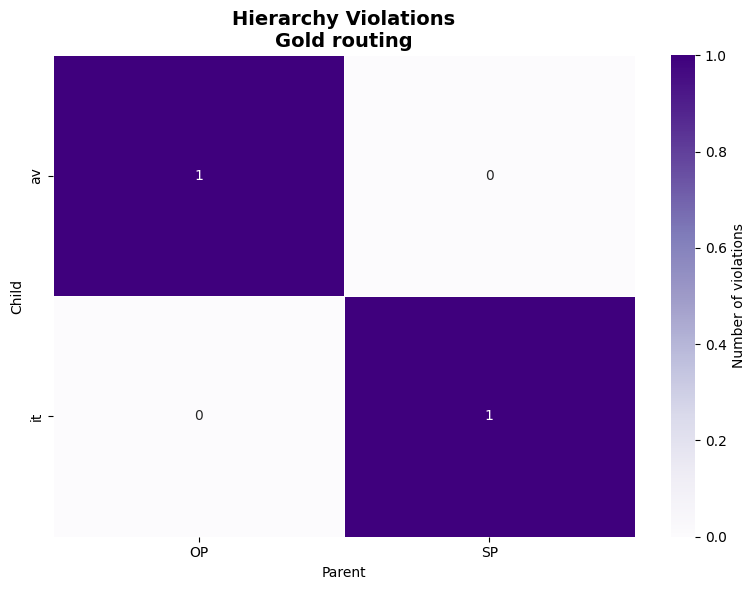

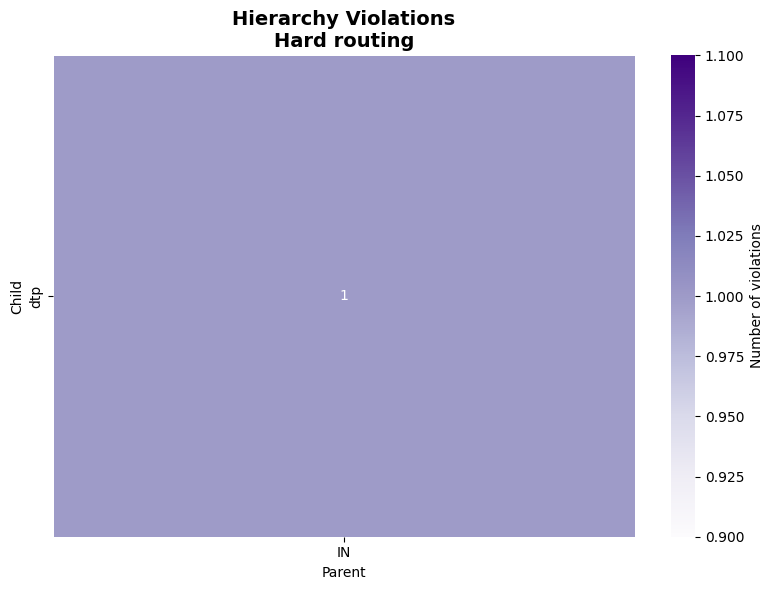

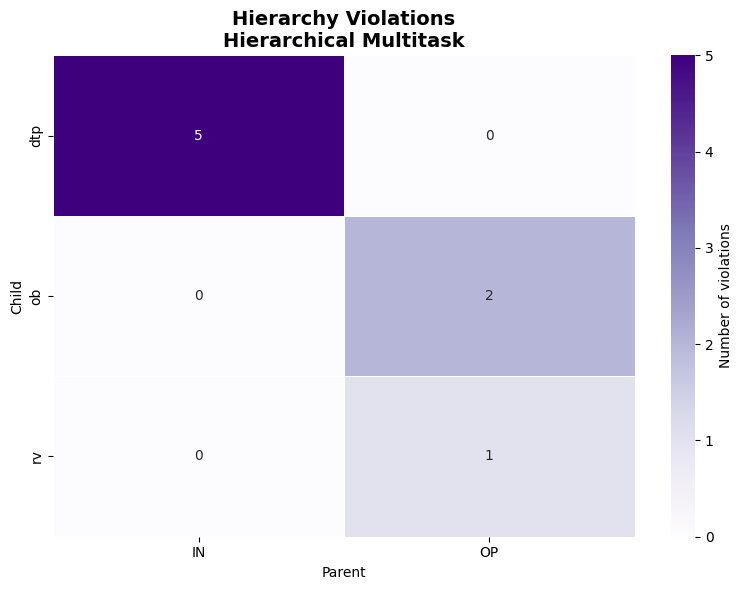

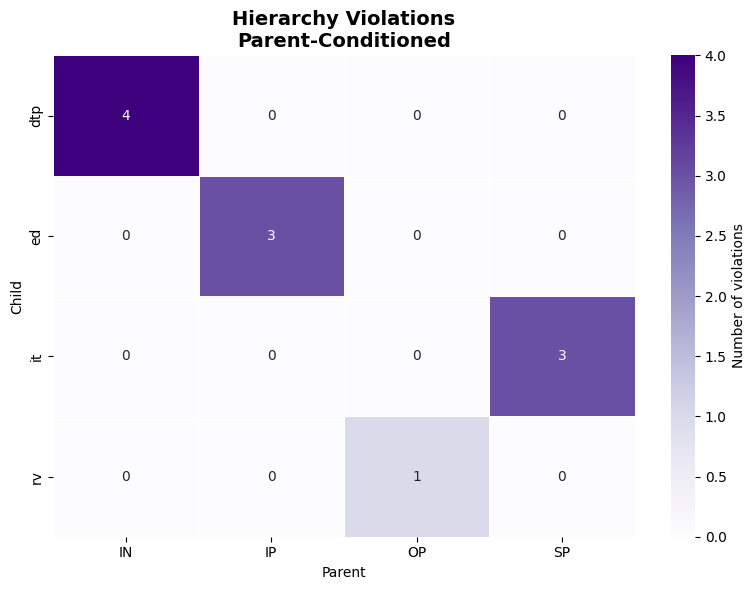

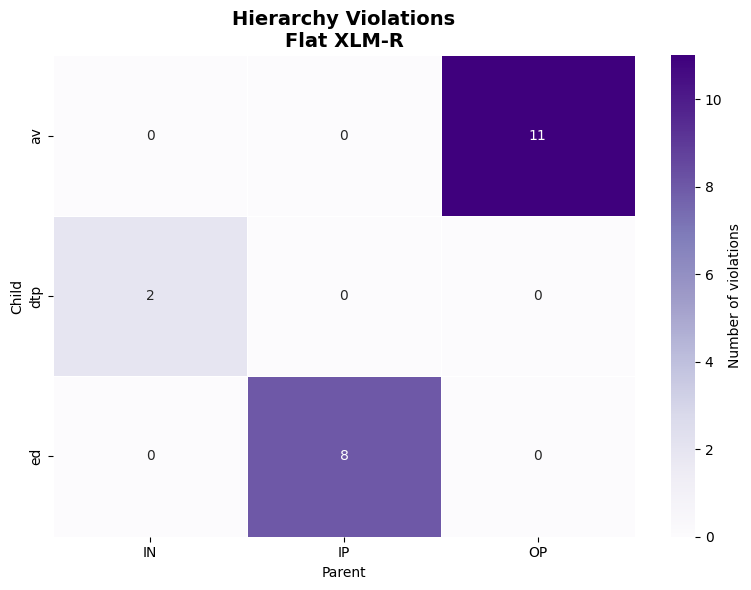

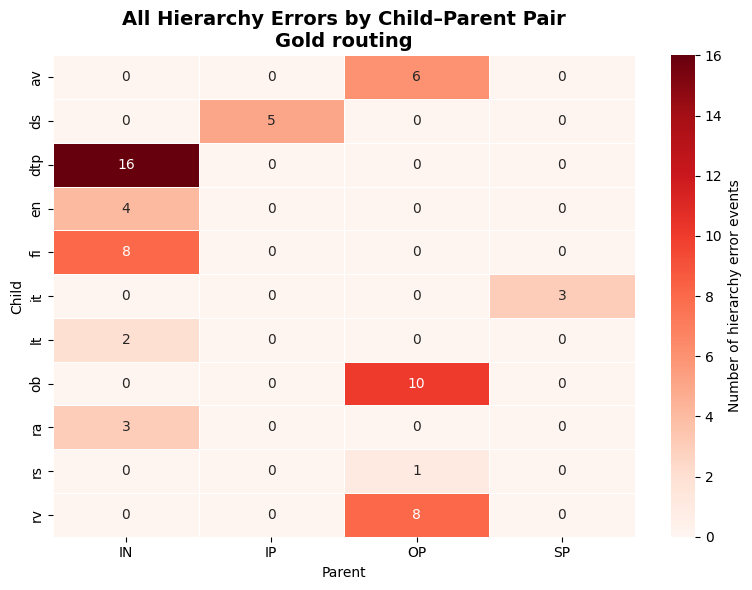

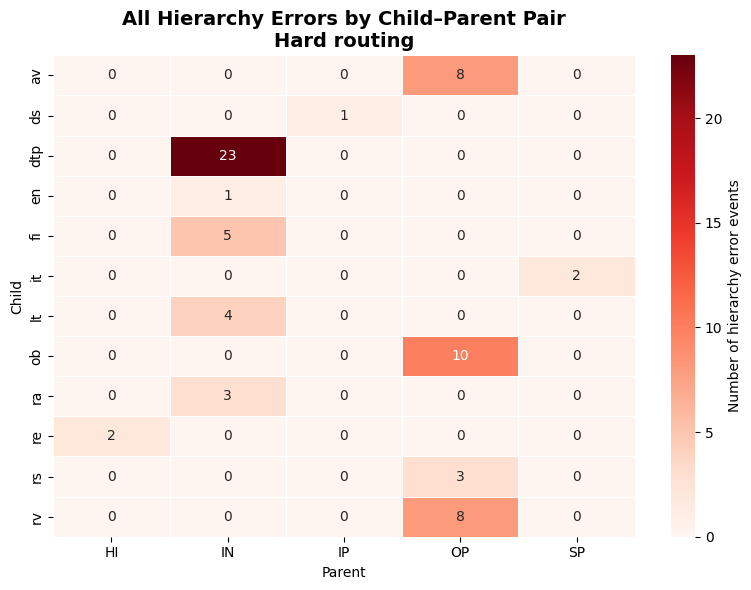

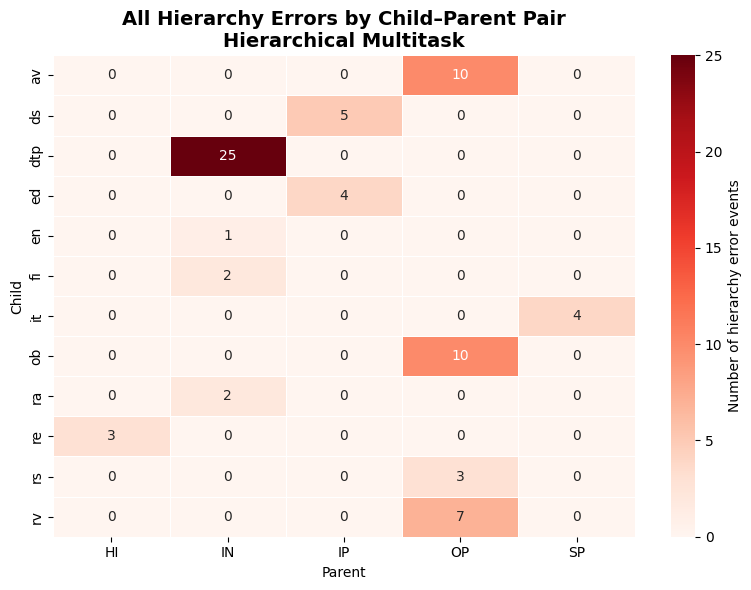

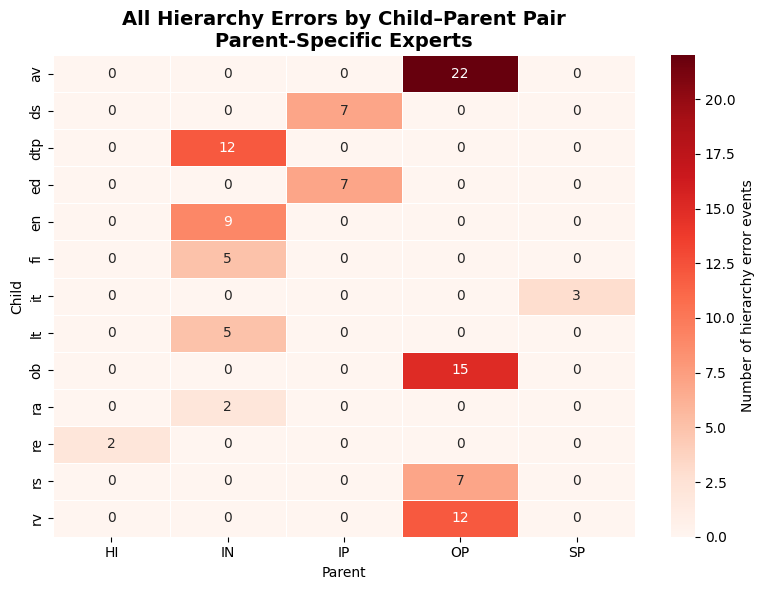

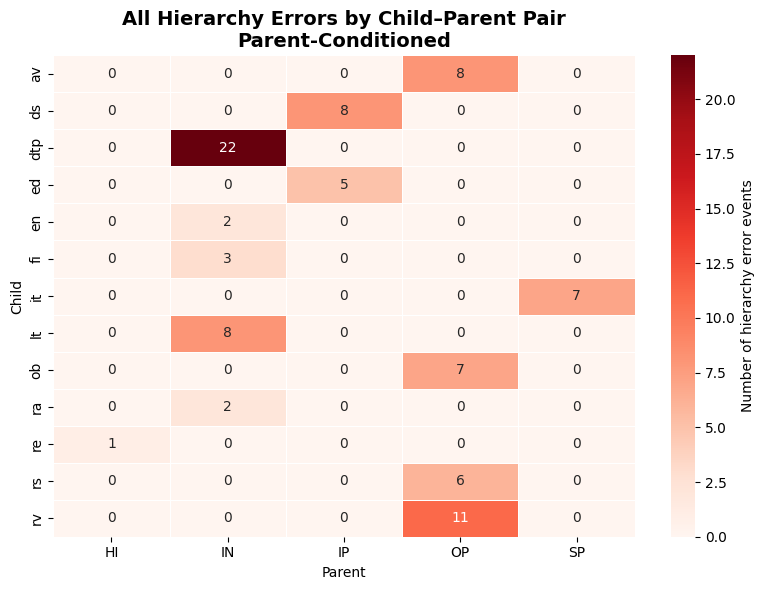

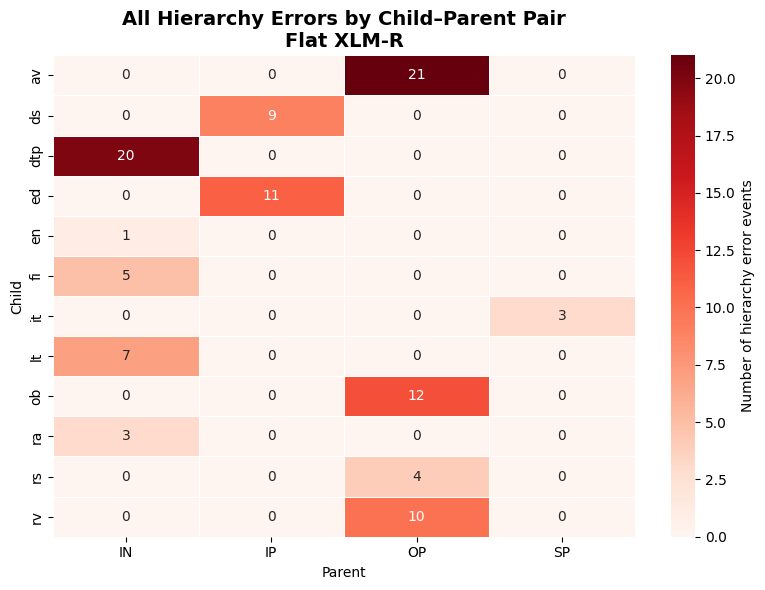



TOP ERROR PAIRS BY EXPERIMENT


Gold routing
--------------------------------------------------------------------------------
            error_type_display     pair  events  unique_documents
Parent predicted, child missed dtp → IN      16                16
Parent predicted, child missed  ob → OP      10                10
Parent predicted, child missed  fi → IN       8                 8
Parent predicted, child missed  rv → OP       8                 8
Parent predicted, child missed  ds → IP       5                 5
Parent predicted, child missed  av → OP       5                 5
Parent predicted, child missed  en → IN       4                 4
Parent predicted, child missed  ra → IN       3                 3
Parent predicted, child missed  lt → IN       2                 2
  Child correct, parent missed  it → SP       1                 1
           Hierarchy violation  it → SP       1                 1
           Hierarchy violation  av → OP       1                 1
Parent predict

In [8]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# ============================================================
# SETTINGS
# ============================================================

DOCUMENT_SUMMARY_CSV_NAME = "per_label_tuned_document_summary.csv"

ROOT = Path(r"C:\Users\alrazz\Downloads")

OUTPUT_DIR = ROOT / "comparison_plots"
SUBFOLDER = "hierarchical_error_analysis"

HIERARCHY_CSV_NAME = "per_label_tuned_hierarchy_errors.csv"

HIERARCHY_OUTPUT_DIR = OUTPUT_DIR / "hierarchy_error_comparison"

HIERARCHY_OUTPUT_DIR.mkdir(
    exist_ok=True
)


# ============================================================
# Find all experiments
# ============================================================

hierarchy_files = list(
    ROOT.glob(
        f"*/{SUBFOLDER}/{HIERARCHY_CSV_NAME}"
    )
)


if not hierarchy_files:

    raise FileNotFoundError(
        f"No files found matching:\n"
        f"{ROOT}\\*\\{SUBFOLDER}\\{HIERARCHY_CSV_NAME}"
    )


print("\nFound hierarchy-error files:")

for f in hierarchy_files:

    print(
        "  ",
        f.parent.parent.name
    )




# ============================================================
# Read all experiments
# ============================================================

hierarchy_experiments = {}


required_columns = {
    "document_index",
    "child",
    "parent",
    "error_type",
    "true_child",
    "true_parent",
    "pred_child",
    "pred_parent",
}


for csv_file in hierarchy_files:

    experiment_name = csv_file.parent.parent.name

    df = pd.read_csv(csv_file)


    missing = (
        required_columns
        - set(df.columns)
    )


    if missing:

        print(
            f"\nWARNING: {experiment_name} "
            f"is missing columns: {missing}"
        )

        continue


    hierarchy_experiments[
        experiment_name
    ] = df


if not hierarchy_experiments:

    raise ValueError(
        "No valid hierarchy-error files found."
    )


# ============================================================
# Standardize error type names
# ============================================================

ERROR_TYPE_NAMES = {

    "parent_predicted_child_not_predicted":
        "Parent predicted, child missed",

    "hierarchy_violation":
        "Hierarchy violation",

    "child_correct_parent_missed":
        "Child correct, parent missed",
}


ERROR_TYPE_ORDER = [

    "parent_predicted_child_not_predicted",

    "hierarchy_violation",

    "child_correct_parent_missed",

]


ERROR_DISPLAY_ORDER = [

    "Parent predicted, child missed",

    "Hierarchy violation",

    "Child correct, parent missed",

]


# ============================================================
# Desired experiment order
# ============================================================

preferred_order = [

    "Gold_routing",
    "Hard_routing",
    "shared_multiCore_XLM-R_diffWeightsBoth",
    "Parent Shared Expert",
    "Parent_Conditioned_Hierarchica",
    "Flat XLMR",

]


available_experiments = list(
    hierarchy_experiments.keys()
)


ordered_experiments = [

    x

    for x in preferred_order

    if x in available_experiments

]


ordered_experiments += [

    x

    for x in available_experiments

    if x not in ordered_experiments

]


# ============================================================
# Display names
# ============================================================

display_experiment_names = {

    "Gold_routing":
        "Gold routing",

    "Hard_routing":
        "Hard routing",

    "shared_multiCore_XLM-R_diffWeightsBoth":
        "Hierarchical Multitask",

    "Parent Shared Expert":
        "Parent-Specific Experts",

    "Parent_Conditioned_Hierarchica":
        "Parent-Conditioned",

    "Flat XLMR":
        "Flat XLM-R",

}


display_names_hierarchy = [

    display_experiment_names.get(
        x,
        x
    )

    for x in ordered_experiments

]


# ============================================================
# 1. EVENT COUNTS BY ERROR TYPE
# ============================================================
#
# Each row in hierarchy_errors.csv is one error event.
#
# A document can therefore contribute multiple events.
#
# ============================================================

event_rows = []


for experiment_name in ordered_experiments:

    df = hierarchy_experiments[
        experiment_name
    ]


    counts = (
        df["error_type"]
        .value_counts()
    )


    for error_type in ERROR_TYPE_ORDER:

        event_rows.append({

            "experiment":
                experiment_name,

            "error_type":
                error_type,

            "error_type_display":
                ERROR_TYPE_NAMES.get(
                    error_type,
                    error_type
                ),

            "count":
                int(
                    counts.get(
                        error_type,
                        0
                    )
                ),

        })


event_counts = pd.DataFrame(
    event_rows
)


# ============================================================
# Save event counts
# ============================================================

event_counts.to_csv(

    HIERARCHY_OUTPUT_DIR
    / "hierarchy_error_event_counts.csv",

    index=False,

    encoding="utf-8-sig",

)


# ============================================================
# Print event counts
# ============================================================

event_pivot = event_counts.pivot(

    index="experiment",

    columns="error_type_display",

    values="count",

).fillna(0)


event_pivot = event_pivot.reindex(
    ordered_experiments
)


event_pivot = event_pivot.reindex(

    columns=ERROR_DISPLAY_ORDER,

    fill_value=0,

)


print("\n")
print("=" * 100)
print("HIERARCHY ERROR EVENTS")
print("=" * 100)

print(
    event_pivot.to_string()
)


# ============================================================
# 2. UNIQUE DOCUMENTS AFFECTED
# ============================================================
#
# This is often more informative than event counts.
#
# Example:
#
# One document may have:
#
#     fi -> IN hierarchy violation
#     lt -> IN hierarchy violation
#
# That produces 2 events but only 1 affected document.
#
# ============================================================

document_rows = []


for experiment_name in ordered_experiments:

    df = hierarchy_experiments[
        experiment_name
    ]


    total_error_documents = (
        df["document_index"]
        .nunique()
    )


    for error_type in ERROR_TYPE_ORDER:

        subset = df[
            df["error_type"]
            == error_type
        ]


        unique_documents = (
            subset["document_index"]
            .nunique()
        )


        document_rows.append({

            "experiment":
                experiment_name,

            "error_type":
                error_type,

            "error_type_display":
                ERROR_TYPE_NAMES.get(
                    error_type,
                    error_type
                ),

            "unique_documents":
                unique_documents,

            "all_hierarchy_error_documents":
                total_error_documents,

        })


unique_document_counts = pd.DataFrame(
    document_rows
)


unique_document_counts.to_csv(

    HIERARCHY_OUTPUT_DIR
    / "hierarchy_error_unique_documents.csv",

    index=False,

    encoding="utf-8-sig",

)


# ============================================================
# Print unique-document counts
# ============================================================

unique_doc_pivot = (
    unique_document_counts
    .pivot(
        index="experiment",
        columns="error_type_display",
        values="unique_documents",
    )
    .fillna(0)
)


unique_doc_pivot = unique_doc_pivot.reindex(
    ordered_experiments
)


unique_doc_pivot = unique_doc_pivot.reindex(

    columns=ERROR_DISPLAY_ORDER,

    fill_value=0,

)


print("\n")
print("=" * 100)
print("UNIQUE DOCUMENTS AFFECTED BY EACH ERROR TYPE")
print("=" * 100)

print(
    unique_doc_pivot.to_string()
)


# ============================================================
# 3. ERROR TYPE PERCENTAGES
# ============================================================
#
# Percentage of ALL TEST DOCUMENTS.
#
# The document-summary CSV contains aggregate rows, so we
# determine the total number of test documents as:
#
#     exact_match + any_error
#
# ============================================================

percentage_rows = []


for experiment_name in ordered_experiments:

    hierarchy_df = hierarchy_experiments[
        experiment_name
    ]


    # --------------------------------------------------------
    # Get total number of test documents
    # --------------------------------------------------------

    summary_file = (
        ROOT
        / experiment_name
        / SUBFOLDER
        / DOCUMENT_SUMMARY_CSV_NAME
    )


    if summary_file.exists():

        summary_df = pd.read_csv(
            summary_file
        )


        exact_count = summary_df.loc[
            summary_df["category"] == "exact_match",
            "count"
        ]


        any_error_count = summary_df.loc[
            summary_df["category"] == "any_error",
            "count"
        ]


        if (
            len(exact_count) == 1
            and
            len(any_error_count) == 1
        ):

            total_documents = (
                int(exact_count.iloc[0])
                +
                int(any_error_count.iloc[0])
            )


        else:

            print(
                f"WARNING: Could not determine total documents "
                f"from {summary_file}"
            )

            total_documents = np.nan


    else:

        print(
            f"WARNING: Document summary not found for "
            f"{experiment_name}: {summary_file}"
        )

        total_documents = np.nan


    # --------------------------------------------------------
    # Calculate percentages for each hierarchy error type
    # --------------------------------------------------------

    for error_type in ERROR_TYPE_ORDER:

        subset = hierarchy_df[
            hierarchy_df["error_type"]
            == error_type
        ]


        event_count = len(
            subset
        )


        unique_documents = (
            subset["document_index"]
            .nunique()
        )


        if (
            pd.notna(total_documents)
            and
            total_documents > 0
        ):

            # Total error events per 100 test documents
            event_percentage = (
                event_count
                / total_documents
                * 100
            )


            # Percentage of test documents affected
            document_percentage = (
                unique_documents
                / total_documents
                * 100
            )


        else:

            event_percentage = np.nan

            document_percentage = np.nan


        percentage_rows.append({

            "experiment":
                experiment_name,

            "total_test_documents":
                total_documents,

            "error_type":
                error_type,

            "error_type_display":
                ERROR_TYPE_NAMES.get(
                    error_type,
                    error_type
                ),

            "event_count":
                event_count,

            "event_percentage":
                event_percentage,

            "unique_documents":
                unique_documents,

            "document_percentage":
                document_percentage,

        })


hierarchy_percentages = pd.DataFrame(
    percentage_rows
)


hierarchy_percentages.to_csv(

    HIERARCHY_OUTPUT_DIR
    / "hierarchy_error_percentages.csv",

    index=False,

    encoding="utf-8-sig",

)


# ============================================================
# 4. PLOT:
# ERROR TYPE EVENT COUNTS
# ============================================================

ERROR_COLORS = {

    "Parent predicted, child missed":
        "#F2C14E",

    "Hierarchy violation":
        "#7B61A8",

    "Child correct, parent missed":
        "#D95F59",

}


plot_data = event_pivot.copy()


fig, ax = plt.subplots(
    figsize=(13, 7)
)


x = np.arange(
    len(plot_data)
)

width = 0.25


for j, category in enumerate(
    ERROR_DISPLAY_ORDER
):

    values = (
        plot_data[category]
        .values
    )


    bars = ax.bar(

        x
        + (
            j
            - 1
        ) * width,

        values,

        width,

        label=category,

        color=ERROR_COLORS[
            category
        ],

    )


    for bar in bars:

        height = bar.get_height()


        if height > 0:

            ax.text(

                bar.get_x()
                + bar.get_width() / 2,

                height + max(
                    plot_data.max().max()
                    * 0.01,
                    0.2
                ),

                f"{int(height)}",

                ha="center",

                va="bottom",

                fontsize=9,

            )


ax.set_xticks(x)

ax.set_xticklabels(

    display_names_hierarchy,

    rotation=25,

    ha="right",

)


ax.set_ylabel(
    "Number of error events"
)


ax.set_title(

    "Hierarchy Error Types Across Approaches",

    fontsize=16,

    fontweight="bold",

)


ax.legend(
    frameon=False
)


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)


ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.tight_layout()


output = (

    HIERARCHY_OUTPUT_DIR
    / "hierarchy_error_types_counts.png"

)


plt.savefig(

    output,

    dpi=300,

    bbox_inches="tight",

)


plt.show()


print(
    f"\nSaved: {output}"
)


# ============================================================
# 5. PLOT:
# UNIQUE DOCUMENTS BY ERROR TYPE
# ============================================================

plot_data = unique_doc_pivot.copy()


fig, ax = plt.subplots(
    figsize=(13, 7)
)


x = np.arange(
    len(plot_data)
)

width = 0.25


for j, category in enumerate(
    ERROR_DISPLAY_ORDER
):

    values = (
        plot_data[category]
        .values
    )


    bars = ax.bar(

        x
        + (
            j
            - 1
        ) * width,

        values,

        width,

        label=category,

        color=ERROR_COLORS[
            category
        ],

    )


    for bar in bars:

        height = bar.get_height()


        if height > 0:

            ax.text(

                bar.get_x()
                + bar.get_width() / 2,

                height + max(
                    plot_data.max().max()
                    * 0.01,
                    0.2
                ),

                f"{int(height)}",

                ha="center",

                va="bottom",

                fontsize=9,

            )


ax.set_xticks(x)

ax.set_xticklabels(

    display_names_hierarchy,

    rotation=25,

    ha="right",

)


ax.set_ylabel(
    "Unique documents"
)


ax.set_title(

    "Documents Affected by Each Hierarchy Error Type",

    fontsize=16,

    fontweight="bold",

)


ax.legend(
    frameon=False
)


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)


ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.tight_layout()


output = (

    HIERARCHY_OUTPUT_DIR
    / "hierarchy_error_types_documents.png"

)


plt.savefig(

    output,

    dpi=300,

    bbox_inches="tight",

)


plt.show()


print(
    f"\nSaved: {output}"
)


# ============================================================
# 6. CHILD -> PARENT ERROR PAIR ANALYSIS
# ============================================================
#
# Example:
#
#     fi -> IN
#     lt -> IN
#     ne -> NA
#
# This lets you determine WHICH hierarchy relationships are
# causing the problems.
#
# ============================================================

pair_rows = []


for experiment_name in ordered_experiments:

    df = hierarchy_experiments[
        experiment_name
    ].copy()


    df["pair"] = (
        df["child"]
        + " → "
        + df["parent"]
    )


    grouped = (

        df.groupby(
            [
                "error_type",
                "child",
                "parent",
                "pair",
            ]
        )

        .agg(

            events=(
                "document_index",
                "count"
            ),

            unique_documents=(
                "document_index",
                "nunique"
            ),

        )

        .reset_index()

    )


    grouped["experiment"] = (
        experiment_name
    )


    pair_rows.append(
        grouped
    )


pair_data = pd.concat(
    pair_rows,
    ignore_index=True
)


pair_data["error_type_display"] = (

    pair_data["error_type"]

    .map(ERROR_TYPE_NAMES)

)


pair_data.to_csv(

    HIERARCHY_OUTPUT_DIR
    / "hierarchy_error_pairs_all.csv",

    index=False,

    encoding="utf-8-sig",

)


# ============================================================
# 7. TOP ERROR PAIRS ACROSS ALL EXPERIMENTS
# ============================================================

top_pairs = (

    pair_data

    .groupby(
        [
            "error_type_display",
            "child",
            "parent",
            "pair",
        ]
    )

    .agg(

        total_events=(
            "events",
            "sum"
        ),

        total_unique_document_counts=(
            "unique_documents",
            "sum"
        ),

    )

    .reset_index()

    .sort_values(
        "total_events",
        ascending=False
    )

)


print("\n")
print("=" * 100)
print("TOP HIERARCHY ERROR PAIRS ACROSS ALL EXPERIMENTS")
print("=" * 100)

print(

    top_pairs.head(30).to_string(
        index=False
    )

)


top_pairs.to_csv(

    HIERARCHY_OUTPUT_DIR
    / "top_hierarchy_error_pairs.csv",

    index=False,

    encoding="utf-8-sig",

)


# ============================================================
# 8. HEATMAP:
# HIERARCHY VIOLATIONS BY CHILD -> PARENT
# ============================================================
#
# Focus specifically on:
#
#     hierarchy_violation
#
# ============================================================

for experiment_name in ordered_experiments:

    df = hierarchy_experiments[
        experiment_name
    ]


    violation_df = df[

        df["error_type"]
        == "hierarchy_violation"

    ]


    if len(violation_df) == 0:

        continue


    pair_counts = (

        violation_df

        .groupby(
            [
                "child",
                "parent",
            ]
        )

        .size()

        .reset_index(
            name="count"
        )

    )


    heatmap_data = (

        pair_counts

        .pivot(
            index="child",
            columns="parent",
            values="count"
        )

        .fillna(0)

    )


    # Keep only actual relationships present in the data

    heatmap_data = heatmap_data.astype(int)


    if heatmap_data.empty:

        continue


    display_experiment = (
        display_experiment_names.get(
            experiment_name,
            experiment_name
        )
    )


    fig, ax = plt.subplots(
        figsize=(8, 6)
    )


    sns.heatmap(

        heatmap_data,

        annot=True,

        fmt="d",

        cmap="Purples",

        linewidths=0.5,

        cbar_kws={
            "label":
            "Number of violations"
        },

        ax=ax,

    )


    ax.set_xlabel(
        "Parent"
    )

    ax.set_ylabel(
        "Child"
    )


    ax.set_title(

        f"Hierarchy Violations\n"
        f"{display_experiment}",

        fontsize=14,

        fontweight="bold",

    )


    plt.tight_layout()


    safe_name = (
        experiment_name
        .replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "_")
    )


    output = (

        HIERARCHY_OUTPUT_DIR
        / f"{safe_name}_hierarchy_violation_heatmap.png"

    )


    plt.savefig(

        output,

        dpi=300,

        bbox_inches="tight",

    )


    plt.show()


# ============================================================
# 9. HEATMAP:
# ALL HIERARCHY ERROR EVENTS
# ============================================================
#
# For each experiment, show total errors for each child-parent
# relationship regardless of error type.
#
# ============================================================

for experiment_name in ordered_experiments:

    df = hierarchy_experiments[
        experiment_name
    ]


    pair_counts = (

        df

        .groupby(
            [
                "child",
                "parent",
            ]
        )

        .size()

        .reset_index(
            name="count"
        )

    )


    if pair_counts.empty:

        continue


    heatmap_data = (

        pair_counts

        .pivot(
            index="child",
            columns="parent",
            values="count"
        )

        .fillna(0)

        .astype(int)

    )


    display_experiment = (
        display_experiment_names.get(
            experiment_name,
            experiment_name
        )
    )


    fig, ax = plt.subplots(
        figsize=(8, 6)
    )


    sns.heatmap(

        heatmap_data,

        annot=True,

        fmt="d",

        cmap="Reds",

        linewidths=0.5,

        cbar_kws={
            "label":
            "Number of hierarchy error events"
        },

        ax=ax,

    )


    ax.set_xlabel(
        "Parent"
    )

    ax.set_ylabel(
        "Child"
    )


    ax.set_title(

        f"All Hierarchy Errors by Child–Parent Pair\n"
        f"{display_experiment}",

        fontsize=14,

        fontweight="bold",

    )


    plt.tight_layout()


    safe_name = (
        experiment_name
        .replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "_")
    )


    output = (

        HIERARCHY_OUTPUT_DIR
        / f"{safe_name}_all_hierarchy_error_heatmap.png"

    )


    plt.savefig(

        output,

        dpi=300,

        bbox_inches="tight",

    )


    plt.show()


# ============================================================
# 10. BEST / WORST ERROR PAIRS FOR EACH EXPERIMENT
# ============================================================

print("\n")
print("=" * 100)
print("TOP ERROR PAIRS BY EXPERIMENT")
print("=" * 100)


for experiment_name in ordered_experiments:

    experiment_pairs = pair_data[

        pair_data["experiment"]
        == experiment_name

    ]


    experiment_pairs = (

        experiment_pairs

        .sort_values(
            "events",
            ascending=False
        )

    )


    print("\n")
    print(
        display_experiment_names.get(
            experiment_name,
            experiment_name
        )
    )

    print("-" * 80)


    if experiment_pairs.empty:

        print(
            "No hierarchy errors."
        )

        continue


    print(

        experiment_pairs[

            [
                "error_type_display",
                "pair",
                "events",
                "unique_documents",

            ]

        ]

        .head(15)

        .to_string(
            index=False
        )

    )


# ============================================================
# 11. COMBINED SUMMARY TABLE
# ============================================================
#
# This gives a compact table useful for comparing experiments.
#
# ============================================================

combined_rows = []


for experiment_name in ordered_experiments:

    df = hierarchy_experiments[
        experiment_name
    ]


    total_events = len(df)


    total_documents_with_errors = (
        df["document_index"]
        .nunique()
    )


    row = {

        "experiment":
            experiment_name,

        "total_hierarchy_error_events":
            total_events,

        "documents_with_hierarchy_errors":
            total_documents_with_errors,

    }


    for error_type in ERROR_TYPE_ORDER:

        subset = df[

            df["error_type"]
            == error_type

        ]


        display_name = ERROR_TYPE_NAMES[
            error_type
        ]


        row[
            display_name
            + " events"
        ] = len(subset)


        row[
            display_name
            + " documents"
        ] = (
            subset["document_index"]
            .nunique()
        )


    combined_rows.append(
        row
    )


combined_summary = pd.DataFrame(
    combined_rows
)


combined_summary = (
    combined_summary
    .set_index("experiment")
    .reindex(ordered_experiments)
)


combined_summary.index = (
    display_names_hierarchy
)


combined_summary.to_csv(

    HIERARCHY_OUTPUT_DIR
    / "hierarchy_error_combined_summary.csv",

    encoding="utf-8-sig",

)


print("\n")
print("=" * 100)
print("COMBINED HIERARCHY ERROR SUMMARY")
print("=" * 100)

print(
    combined_summary.to_string()
)


# ============================================================
# 12. FINAL OUTPUT LOCATION
# ============================================================

print("\n")
print("=" * 100)
print("HIERARCHY ERROR ANALYSIS COMPLETE")
print("=" * 100)

print(
    "\nResults saved to:"
)

print(
    HIERARCHY_OUTPUT_DIR
)

print("\nImportant files:")

print(
    "  hierarchy_error_event_counts.csv"
)

print(
    "  hierarchy_error_unique_documents.csv"
)

print(
    "  hierarchy_error_percentages.csv"
)

print(
    "  hierarchy_error_pairs_all.csv"
)

print(
    "  top_hierarchy_error_pairs.csv"
)

print(
    "  hierarchy_error_combined_summary.csv"
)

print("=" * 100)